In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

## After training (V1)

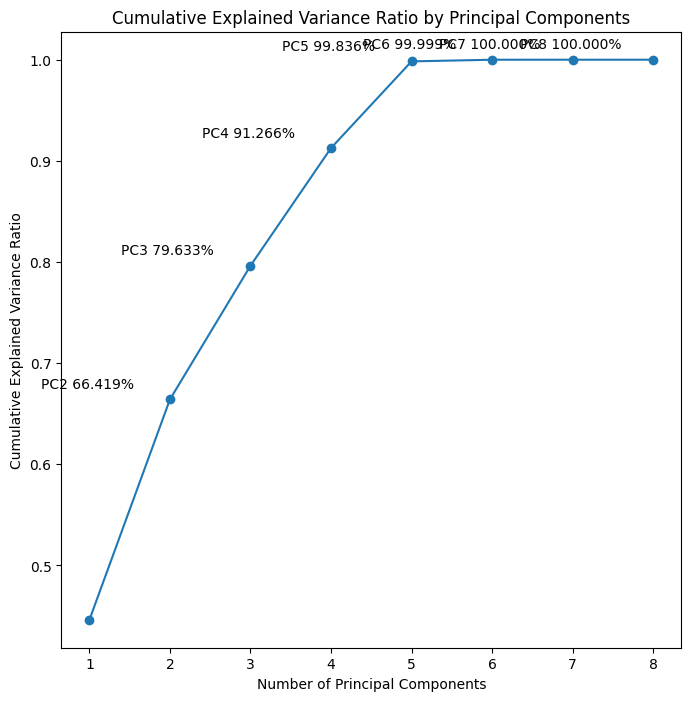

In [6]:
import os
from utils.explained_variance_ratio import explained_variance
from script.shell import MinimalTransformer # this dimension and all the params should match the file saved in .pth
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)

checkpoint_dir = os.path.join(PROJECT_ROOT, 'checkpoints')
file_name = 'v1.pth'
full_path = os.path.join(checkpoint_dir, file_name)


explained_variance(full_path, model=model, pc=8)

## V(2)


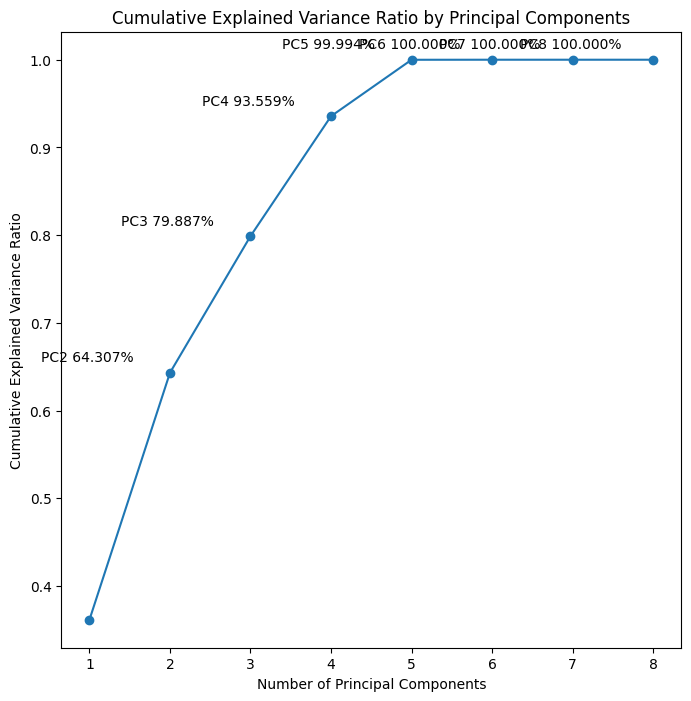

In [7]:
from script.shell import MinimalTransformer
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
explained_variance(os.path.join(checkpoint_dir, 'v2.pth'), model, pc=8)

V(3)

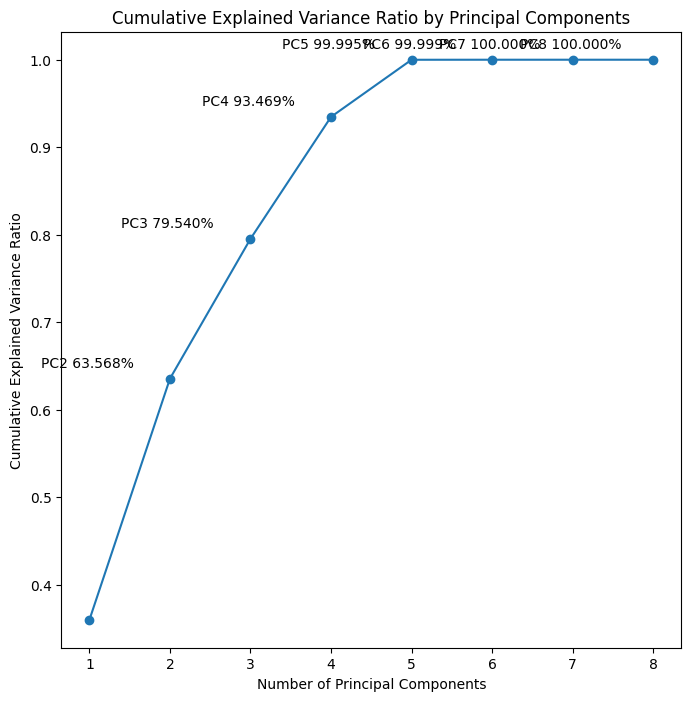

In [8]:
from script.shell import MinimalTransformer 
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)

explained_variance(os.path.join(checkpoint_dir, 'v3.pth'), model, pc=8)

## Before training

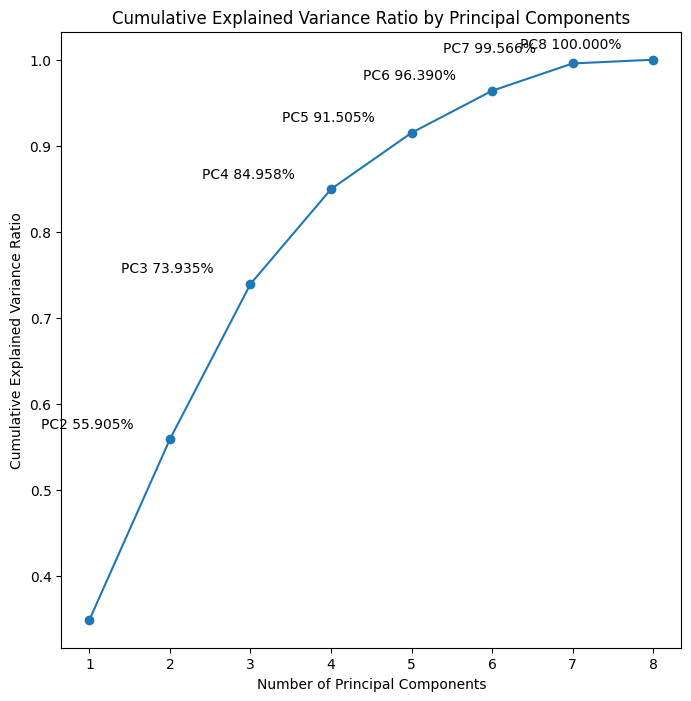

In [9]:
from script.shell import MinimalTransformer
file_name = 'v1_initial.pth'
full_path = os.path.join(checkpoint_dir, file_name)
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
explained_variance(full_path, model, pc=8)

## Dimensional reduction explained variance ratio

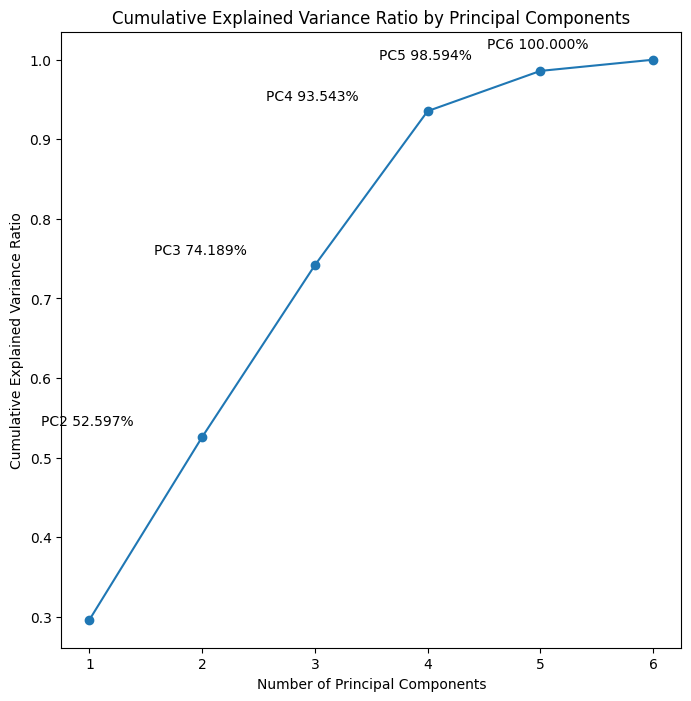

In [10]:
from script.model_dim_6 import MinimalTransformer 
vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
checkpoint_dir = '../checkpoints'
explained_variance(os.path.join(checkpoint_dir, 'dim_6_mlp.pth'), model, pc=6)

## Dimensional reduction, with accuracy plot

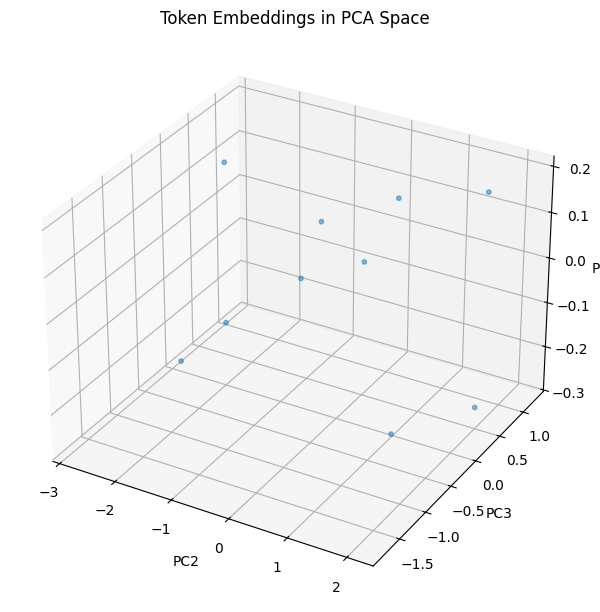

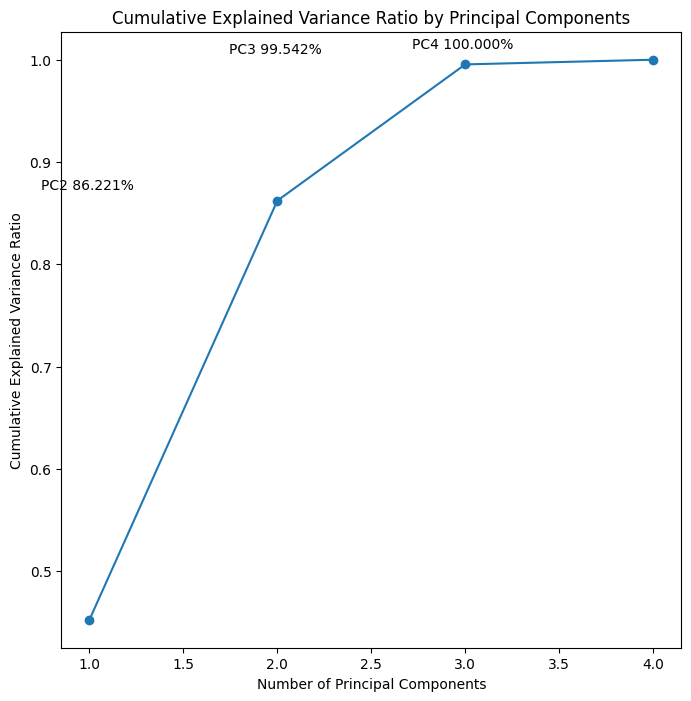

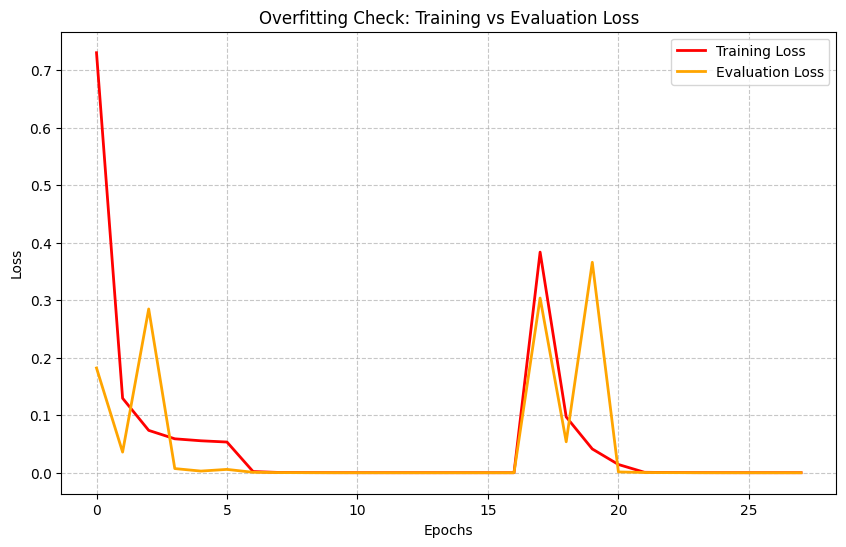

In [30]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utils.explained_variance_ratio import explained_variance, overfitting_plot
from script.model_dim_4_layer_3 import MinimalTransformer 


vocab_size = 10
model = MinimalTransformer(vocab_size=vocab_size)
checkpoint_dir = '../checkpoints'
full_path = os.path.join(checkpoint_dir, 'dim_4_layer_3.pth')

checkpoint = torch.load(full_path)

train_plot = checkpoint['train_loss_history']
eval_plot = checkpoint['eval_loss_history']

def plot_3d(full_path, model, pc):


    if not os.path.exists(full_path):
        sys.exit()  

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    try:
        model.load_state_dict(torch.load(full_path, map_location=device)) 
    except Exception:
        model.load_state_dict(torch.load(full_path, map_location=device)['model_state_dict'])
    pca = PCA(n_components=pc) 
    embedding_learned = model.token_embed
    embedding_matrix = embedding_learned.weight.detach()
    X = embedding_matrix.cpu().numpy() 
    pca.fit(X)
    X_transformed = pca.transform(X) 
    # skipping PC1 cause it does not contain much information
    x = X_transformed[:, 1]
    y = X_transformed[:, 2]
    z = X_transformed[:, 3]

    fig = plt.figure(figsize=(6, 18))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x, y, z, alpha=0.5, s=10)

    ax.set_xlabel('PC2')
    ax.set_ylabel('PC3')
    ax.set_zlabel('PC4')
    ax.set_title('Token Embeddings in PCA Space')

    plt.tight_layout()
    plt.show()

plot_3d(full_path, model, pc=4)
explained_variance(full_path, model, pc=4)
overfitting_plot(train_plot, eval_plot)
